In [1]:
import sys, os

# Fix path
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
SRC_DIR      = os.path.join(PROJECT_ROOT, "src")

for p in [SRC_DIR, PROJECT_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Check Python version
print(f"Python version: {sys.version}")
print(f"SRC exists: {os.path.exists(SRC_DIR)}")
print(f"SRC path: {SRC_DIR}")

os.makedirs(os.path.join(PROJECT_ROOT, 'models'), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, 'results'), exist_ok=True)

import json
import numpy as np
import matplotlib.pyplot as plt

# Try importing keras
try:
    from tensorflow import keras
    from tensorflow.keras import layers, callbacks
    print(f"✅ TensorFlow keras: {keras.__version__}")
except:
    import keras
    from keras import layers, callbacks
    print(f"✅ Standalone keras: {keras.__version__}")

from preprocess import run_preprocessing_pipeline, FEATURE_COLS, SEQ_LENGTH

plt.style.use('dark_background')
np.random.seed(42)
print(f"✅ SEQ_LENGTH: {SEQ_LENGTH}")
print(f"✅ All imports successful!")

Python version: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
SRC exists: True
SRC path: c:\Users\HP\ecocharge\src
✅ Standalone keras: 2.13.1
✅ SEQ_LENGTH: 30
✅ All imports successful!


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers, callbacks
from preprocess import run_preprocessing_pipeline, FEATURE_COLS, SEQ_LENGTH

plt.style.use('dark_background')
np.random.seed(42)
print(f"✅ Keras: {keras.__version__}")
print(f"✅ run_preprocessing_pipeline imported!")

✅ Keras: 2.13.1
✅ run_preprocessing_pipeline imported!


In [3]:
HPARAMS = {
    'lstm_units_1':  32,   # reduced from 128
    'lstm_units_2':  16,   # reduced from 64
    'dense_units':   16,   # reduced from 32
    'dropout_rate':  0.2,
    'learning_rate': 1e-3,
    'batch_size':    16,   # reduced from 32
    'epochs':        10,   # reduced from 20
    'patience':      3,
}
print("✅ Lightweight HPARAMS set!")

✅ Lightweight HPARAMS set!


In [4]:
X_train, X_val, X_test, y_train, y_val, y_test = run_preprocessing_pipeline()

print(f"✅ X_train : {X_train.shape}")
print(f"✅ X_val   : {X_val.shape}")
print(f"✅ X_test  : {X_test.shape}")
print(f"✅ Capacity range: {y_train.min():.4f} to {y_train.max():.4f} Ah")

[preprocess] Loaded  636 rows, 9 columns.
[preprocess] Cleaned 0 bad rows.  Remaining: 636
[preprocess] Features engineered. New cols: soh, capacity_fade, resistance_proxy
[preprocess] Scaler fitted and saved → c:\Users\HP\ecocharge\src\..\models\scaler.pkl
[preprocess] Processed data saved → c:\Users\HP\ecocharge\src\..\data\processed\battery_processed.csv
[preprocess] Sequences created — X: (516, 30, 7), y: (516,)
[preprocess] Split — Train: 361  Val: 77  Test: 78
✅ X_train : (361, 30, 7)
✅ X_val   : (77, 30, 7)
✅ X_test  : (78, 30, 7)
✅ Capacity range: 1.1538 to 1.9248 Ah


c:\Users\HP\ecocharge\src\preprocess.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('battery_id', group_keys=False).apply(lambda g: g.ffill().bfill())


In [5]:
def build_model(seq_length, n_features, hparams):
    inp = keras.Input(shape=(seq_length, n_features), name='battery_sequence')
    x = layers.LSTM(hparams['lstm_units_1'], return_sequences=True, name='lstm_1')(inp)
    x = layers.Dropout(hparams['dropout_rate'], name='dropout_1')(x)
    x = layers.LSTM(hparams['lstm_units_2'], return_sequences=False, name='lstm_2')(x)
    x = layers.Dropout(hparams['dropout_rate'], name='dropout_2')(x)
    x = layers.Dense(hparams['dense_units'], activation='relu', name='dense_1')(x)
    x = layers.BatchNormalization(name='batchnorm')(x)
    out = layers.Dense(1, name='output')(x)
    model = keras.Model(inputs=inp, outputs=out, name='EcoCharge_LSTM')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hparams['learning_rate']),
        loss='mse',
        metrics=['mae', keras.metrics.RootMeanSquaredError(name='rmse')],
    )
    return model

model = build_model(SEQ_LENGTH, len(FEATURE_COLS), HPARAMS)
model.summary()
print("✅ Model built!")

Model: "EcoCharge_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 battery_sequence (InputLay  [(None, 30, 7)]           0         
 er)                                                             
                                                                 
 lstm_1 (LSTM)               (None, 30, 32)            5120      
                                                                 
 dropout_1 (Dropout)         (None, 30, 32)            0         
                                                                 
 lstm_2 (LSTM)               (None, 16)                3136      
                                                                 
 dropout_2 (Dropout)         (None, 16)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                272       
                                                    

In [6]:
MODEL_PATH  = os.path.join(PROJECT_ROOT, 'models', 'lstm_model.keras')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
os.makedirs(os.path.join(PROJECT_ROOT, 'models'), exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

cb_list = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=HPARAMS['patience'],
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
        save_format='h5'
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=HPARAMS['epochs'],
    batch_size=HPARAMS['batch_size'],
    callbacks=cb_list,
    verbose=1,
)
print(f"\n✅ Training complete!")
print(f"   Best val_loss : {min(history.history['val_loss']):.6f}")
print(f"   Best val_mae  : {min(history.history['val_mae']):.6f}")
print(f"   Epochs run    : {len(history.history['loss'])}")

Epoch 1/10
23/23 [==============================] - ETA: 0s - loss: 2.6708 - mae: 1.4625 - rmse: 1.6343
Epoch 1: val_loss improved from inf to 1.80450, saving model to c:\Users\HP\ecocharge\models\lstm_model.keras
23/23 [==============================] - 8s 86ms/step - loss: 2.6708 - mae: 1.4625 - rmse: 1.6343 - val_loss: 1.8045 - val_mae: 1.3340 - val_rmse: 1.3433 - lr: 0.0010
Epoch 2/10
 1/23 [>.............................] - ETA: 0s - loss: 1.9242 - mae: 1.3592 - rmse: 1.3871

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


22/23 [===========================>..] - ETA: 0s - loss: 1.8318 - mae: 1.3153 - rmse: 1.3534
Epoch 2: val_loss improved from 1.80450 to 1.51717, saving model to c:\Users\HP\ecocharge\models\lstm_model.keras
23/23 [==============================] - 1s 32ms/step - loss: 1.8278 - mae: 1.3141 - rmse: 1.3520 - val_loss: 1.5172 - val_mae: 1.2217 - val_rmse: 1.2317 - lr: 0.0010
Epoch 3/10
23/23 [==============================] - ETA: 0s - loss: 1.4420 - mae: 1.1755 - rmse: 1.2008
Epoch 3: val_loss improved from 1.51717 to 1.19364, saving model to c:\Users\HP\ecocharge\models\lstm_model.keras
23/23 [==============================] - 1s 34ms/step - loss: 1.4420 - mae: 1.1755 - rmse: 1.2008 - val_loss: 1.1936 - val_mae: 1.0800 - val_rmse: 1.0925 - lr: 0.0010
Epoch 4/10
22/23 [===========================>..] - ETA: 0s - loss: 1.1141 - mae: 1.0327 - rmse: 1.0555
Epoch 4: val_loss improved from 1.19364 to 0.89999, saving model to c:\Users\HP\ecocharge\models\lstm_model.keras
23/23 [================

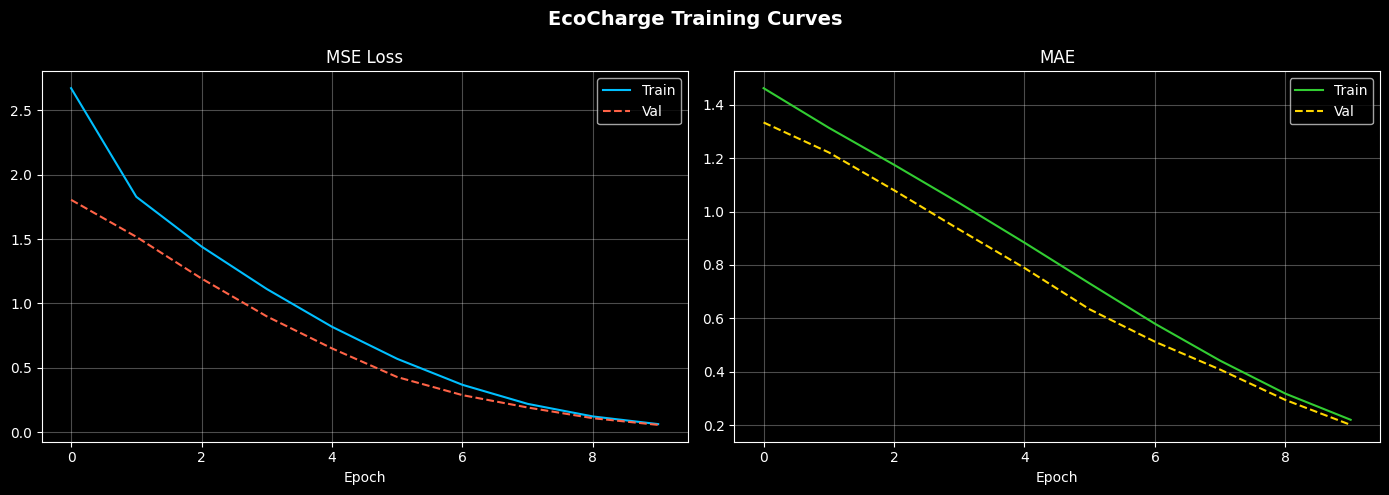

✅ Training curves saved!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     label='Train', color='deepskyblue')
axes[0].plot(history.history['val_loss'], label='Val',   color='tomato', linestyle='--')
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(history.history['mae'],     label='Train', color='limegreen')
axes[1].plot(history.history['val_mae'], label='Val',   color='gold', linestyle='--')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.suptitle('EcoCharge Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=150)
plt.show()
print("✅ Training curves saved!")

In [8]:
model.save(MODEL_PATH)
print(f"✅ Model saved → {MODEL_PATH}")

history_path = os.path.join(PROJECT_ROOT, 'models', 'training_history.json')
with open(history_path, 'w') as f:
    json.dump({k: [float(v) for v in vals]
               for k, vals in history.history.items()}, f, indent=2)
print(f"✅ History saved!")
print("✅ Training complete!")


✅ Model saved → c:\Users\HP\ecocharge\models\lstm_model.keras
✅ History saved!
✅ Training complete!
